# Создание ФЧ и эффективный показаний детектора

Иcходное интегральное уравнение Фредгольма 1-го рода в форме:

\begin{equation}
\int_{E_{\rm min}}^{E_{\rm max}} K_j(E)\,\varphi (E)\, dE
= Q_j ,
\quad j=1,\ldots,M,
\end{equation}

для М шаров замедлителей, $K_j(E)$ - ФЧ

Перейдём к интегралу по летаргии $u(E)={\rm lg}(E/E_{\rm min})$. 

\begin{equation}
\ln 10 \times \int_{0}^{l_E} K_j(u) \,\varphi (u)\,E(u)\, du = Q_j,
\quad j=1,\ldots,M.
\end{equation}

И теперь будем искать $\Phi(u) = \varphi(u)E(u)$
Для дискретизации введём равномерную сетку по летаргии с шагом $\Delta u = l_E/(N-1)$, где $N$ -- количество узлов сетки.

Аппроксимируем интеграл методом прямоугольников:

$$
\ln 10 \times \int_{0}^{l_E} K_j(u) \,\varphi (u)\,E(u)\, du \approx \ln 10  \sum_{i=1}^{N} K_j(u_i) \Phi(u_i) \Delta u = Q_j, 
\quad j=1,\ldots,M, i=1,\ldots,N.
$$

Введём обозначения:
$$
\Phi_i = \Phi(u_i),\quad K_{ji} = K_j(u_i),\quad A_{ji} = \ln 10 \cdot \Delta u \cdot K_{ji} 
$$

Получаем линейную систему уравнений:

\begin{equation}
\boxed{
\sum_{i=1}^{N} A_{ji} \Phi_i = Q_j,
\quad j=1,\ldots,M,
}
\end{equation}

В матричной форме система записывается как:
$$
\mathbf{A} \boldsymbol{\Phi} = \mathbf{Q},
$$
где элементы матрицы системы:

где
$$
\mathbf{A} \in \mathbb{R}^{M \times N},\quad
\boldsymbol{\varphi} \in \mathbb{R}^{N},\quad
\mathbf{Q} \in \mathbb{R}^{M}.
$$

Для случая $N > M$ система является недоопределённой и требует регуляризации.

### ФЧ - проблема дискретизации
- Границ бинов при дискретизации на 1 больше чем самих бинов.
- В таблице ФЧ у нас даны значения "слева", т.е. при дискретизации прямоугольником мы считаем, что площадь прямоугольника $\Phi * \Delta u$. Соответственно в последней ячейки мы должны выбрать правую границу прямоугольника.
- поэтому я добавил этк границу продублировав значения ФЧ из предыдущей ячейки (для компендиума правая граница =  631 МэВ - c округлением до 3 знака).
- Нижняя граница тоже разная для разных приборов: $10^{-8}$ или $10^{-9}$ МэВ. (Для тех, у которых нет данных для $10^{-9}$ я продублировал значения с  $10^{-8}$, чтоб был единый стиль). 
- если так не делать, можно взять на 1 шаг больше по $\Delta u$ и сказать что это наша правая граница.
- если $\Delta u_i$ - неравномерна (как в ФЧ из компендиума), то нужно для каждого бина умножить на свою $\Delta u_i$

__можно взять функции:__
 1. Convert_RF()
 1. convert_rf_to_matrix_variable_step()
 2. calculate_Q()
 3. convert_spectre_energy_steps()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.interpolate import pchip, interp1d, griddata, interp2d

from scipy.integrate import quad, trapezoid

import cvxpy as cp

### Преобразование ФЧ под нужную дискретизацию

In [ ]:
# rf_filename = "../Data/Response_functions/RF_JINR.csv"
rf_filename = "Data/Response_functions/RF_JINR.csv"
rf_df = pd.read_csv(rf_filename)

In [24]:
# Создаем массив логарифмических значений с шагом 0.2 -- под диапазон компендиума = 60 бинов
log_min = 0  # 0.01 МэВ (можно настроить под ваши нужды)
log_max = np.log10(630 / 1e-9)
step = 0.2

# Создаем массив логарифмов с шагом 0.2
log_values = np.arange(log_min, log_max + step, step)

# Преобразуем в энергии
new_ebins = 1e-9 * 10**log_values

In [25]:
new_ebins

array([1.00000000e-09, 1.58489319e-09, 2.51188643e-09, 3.98107171e-09,
       6.30957344e-09, 1.00000000e-08, 1.58489319e-08, 2.51188643e-08,
       3.98107171e-08, 6.30957344e-08, 1.00000000e-07, 1.58489319e-07,
       2.51188643e-07, 3.98107171e-07, 6.30957344e-07, 1.00000000e-06,
       1.58489319e-06, 2.51188643e-06, 3.98107171e-06, 6.30957344e-06,
       1.00000000e-05, 1.58489319e-05, 2.51188643e-05, 3.98107171e-05,
       6.30957344e-05, 1.00000000e-04, 1.58489319e-04, 2.51188643e-04,
       3.98107171e-04, 6.30957344e-04, 1.00000000e-03, 1.58489319e-03,
       2.51188643e-03, 3.98107171e-03, 6.30957344e-03, 1.00000000e-02,
       1.58489319e-02, 2.51188643e-02, 3.98107171e-02, 6.30957344e-02,
       1.00000000e-01, 1.58489319e-01, 2.51188643e-01, 3.98107171e-01,
       6.30957344e-01, 1.00000000e+00, 1.58489319e+00, 2.51188643e+00,
       3.98107171e+00, 6.30957344e+00, 1.00000000e+01, 1.58489319e+01,
       2.51188643e+01, 3.98107171e+01, 6.30957344e+01, 1.00000000e+02,
      

In [26]:
def Convert_RF(
    rf_filename, new_ebins, method="pchip", min_value=1e-9, extrapolate=True
):
    """
    Конвертирует функции чувствительности на новую энергетическую сетку
    версия с выбором метода интерполяции

    new_ebins in MeV
    min_value in MeV

    Parameters:
    -----------
    method : str
        Метод интерполяции: 'pchip', 'linear', 'cubic'
    extrapolate : bool
        Разрешить экстраполяцию за пределы исходного диапазона
    """
    if isinstance(rf_filename, str):
        rf_df = pd.read_csv(rf_filename)
    else:
        rf_df = rf_filename.copy()

    if "E_MeV" in rf_df.columns:
        ebinsRF = rf_df["E_MeV"].values
        rf_df = rf_df.drop("E_MeV", axis=1)
    else:
        ebinsRF = rf_df.iloc[:, 0].values
        rf_df = rf_df.iloc[:, 1:]

    # Проверяем, что новый массив энергий не выходит за пределы исходного
    if new_ebins.min() < ebinsRF.min():
        raise ValueError(
            "Новые энергетические бины выходят за пределы исходной сетки по минимальной энергии"
        )
    else:
        if new_ebins.max() > ebinsRF.max():
            raise ValueError(
                "Новые энергетические бины выходят за пределы исходной сетки по максимальной энергии"
            )

        else:
            new_rf_df = pd.DataFrame()
            new_rf_df["E_MeV"] = new_ebins
            # new_rf_df['delta_u'] = np.log10(new_ebins / min_value)

            uRF = np.log10(ebinsRF / min_value)
            u_new = np.log10(new_ebins / min_value)  # новая сетка в лог-шкале
            for sphere in rf_df.columns:
                if method == "pchip":
                    # Логарифмическая интерполяция с PCHIP
                    interpolator = pchip(uRF, rf_df[sphere].values)
                    interpolated_values = interpolator(u_new)

                else:
                    # Другие методы интерполяции
                    interpolator = interp1d(
                        uRF,
                        rf_df[sphere].values,
                        kind=method,
                        bounds_error=not extrapolate,
                        fill_value="extrapolate" if extrapolate else np.nan,
                    )
                    interpolated_values = interpolator(u_new)

                new_rf_df[sphere] = np.where(
                    interpolated_values < 0, 0, interpolated_values
                )  # если при интерполяции получили меньше нуля - то ставим 0

            return new_rf_df

Сохраним в csv

In [27]:
new_rf_df = Convert_RF(
    rf_filename, new_ebins, method="pchip"
)  # pchip лучше всего интерполирует
new_rf_df.to_csv(
    f'{rf_filename[:-4]}_new.csv', index=False
)  # сохраним в файл новые ФЧ

### Просмотр

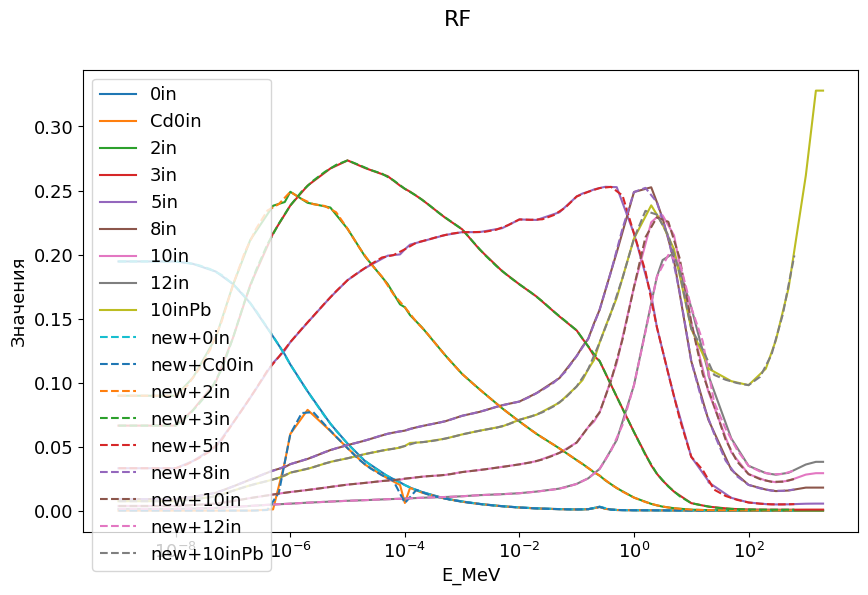

In [28]:
# новые энергии выбраны только до 631 МэВ!
fig = plt.figure(figsize=(10, 6))
fig.suptitle("RF", fontsize=16)
ax = fig.add_subplot(111)
ax.set_xscale("log")

for col in rf_df.columns:
    if col != "E_MeV":
        ax.plot(rf_df["E_MeV"], rf_df[col], label=col)


for col in new_rf_df.columns:
    if col != "E_MeV":
        ax.plot(new_rf_df["E_MeV"], new_rf_df[col], label=f"new+{col}", linestyle="--")


ax.legend(loc="upper left")
ax.set_xlabel("E_MeV")
ax.set_ylabel("Значения")
plt.show()

-----------------

## Теперь как указано выше, надо преобразовать наши ФЧ в матрицу для решения СЛАУ 

$$
\mathbf{A} \boldsymbol{\Phi} = \mathbf{Q},
$$

In [29]:
def convert_rf_to_matrix(rf_df, log_step=0.2):
    """
    Преобразует DataFrame с функциями чувствительности в матрицу,
    умножая на np.log(10) и на шаг по энергии в логарифмическом масштабе

    Parameters:
    -----------
    rf_df : pd.DataFrame
        DataFrame с функциями чувствительности.
        Первая колонка 'E_MeV' - энергии в МэВ.
        Остальные колонки - функции чувствительности для разных сфер.
    log_step : float
        Шаг по логарифму энергии (log10)

    Returns:
    --------
    tuple: (matrix, energies, sphere_names)
        matrix : np.ndarray
            Матрица размером (n_energies, n_spheres)
        energies : np.ndarray
            Массив энергий в МэВ
        sphere_names : list
            Список имен сфер
    """

    # Извлекаем энергии
    if "E_MeV" in rf_df.columns:
        energies = rf_df["E_MeV"].values
        rf_data = rf_df.drop("E_MeV", axis=1)
    else:
        # Предполагаем, что первый столбец - это энергия
        energies = rf_df.iloc[:, 0].values
        rf_data = rf_df.iloc[:, 1:]

    # Получаем имена сфер
    sphere_names = rf_data.columns.tolist()

    # Преобразуем в numpy массив
    rf_array = rf_data.values  # размер: (n_energies, n_spheres)

    # Умножаем на np.log(10) и на шаг по логарифмической шкале
    scaling_factor = np.log(10) * log_step

    # Умножаем всю матрицу на scaling_factor
    rf_matrix = rf_array * scaling_factor

    return rf_matrix, energies, sphere_names

In [30]:
def convert_rf_to_matrix_variable_step(rf_df, Emin=1e-9):
    """
    Преобразует DataFrame с функциями чувствительности в матрицу,
    умножая на np.log(10) и на индивидуальный шаг по логарифмической энергии
    для каждой точки.

    Parameters:
    -----------
    rf_df : pd.DataFrame
        DataFrame с функциями чувствительности.
        Первая колонка 'E_MeV' - энергии в МэВ.
        Остальные колонки - функции чувствительности для разных сфер.

    Returns:
    --------
    tuple: (matrix, energies, sphere_names, log_steps)
        matrix : np.ndarray
            Матрица размером (n_energies, n_spheres)
        energies : np.ndarray
            Массив энергий в МэВ
        sphere_names : list
            Список имен сфер
        log_steps : np.ndarray
            Массив шагов в логарифмической шкале для каждой точки
    """

    # Извлекаем энергии
    if "E_MeV" in rf_df.columns:
        energies = rf_df["E_MeV"].values
        rf_data = rf_df.drop("E_MeV", axis=1)
    else:
        # Предполагаем, что первый столбец - это энергия
        energies = rf_df.iloc[:, 0].values
        rf_data = rf_df.iloc[:, 1:]

    # Получаем имена сфер
    sphere_names = rf_data.columns.tolist()

    # Преобразуем в numpy массив
    rf_array = rf_data.values  # размер: (n_energies, n_spheres)

    # Вычисляем логарифмы энергий
    log_energies = np.log10(energies / Emin)

    # Вычисляем шаги в логарифмической шкале для каждой точки
    # Для внутренних точек используем среднее шагов слева и справа
    # Для граничных точек используем односторонний шаг

    n_points = len(energies)
    log_steps = np.zeros(n_points)

    # Для первой точки
    log_steps[0] = log_energies[1] - log_energies[0]

    # Для последней точки
    log_steps[-1] = log_energies[-1] - log_energies[-2]

    # Для внутренних точек
    for i in range(1, n_points - 1):
        # Средний шаг между левым и правым интервалами
        left_step = log_energies[i] - log_energies[i - 1]
        right_step = log_energies[i + 1] - log_energies[i]
        log_steps[i] = (left_step + right_step) / 2

    # Из-за перехода к логарифмической шкале,  нужно домножить на np.log(10)

    ln_steps = log_steps * np.log(10)

    # Умножаем каждую строку матрицы на соответствующий шаг
    # Используем broadcasting: (n_energies, n_spheres) * (n_energies, 1)
    rf_matrix = rf_array * ln_steps[:, np.newaxis]

    return rf_matrix, energies, sphere_names, log_steps

### Если шаг равный 

In [31]:
A, energies, sphere_names = convert_rf_to_matrix(new_rf_df, log_step=0.2)
with np.printoptions(precision=1, floatmode='fixed'):
    print(A, '\n')


[[9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [8.9e-02 0.0e+00 4.5e-02 3.4e-02 1.7e-02 4.6e-03 1.9e-03 7.0e-04 3.8e-03]
 [8.8e-02 0.0e+00 5.1e-02 3.8e-02 1.9e-02 5.3e-03 2.1e-03 7.9e-04 4.3e-03]
 [8.7e-02 0.0e+00 5.8e-02 4.3e-02 2.1e-02 6.0e-03 2.4e-03 9.0e-04 4.8e-03]
 [8.5e-02 0.0e+00 6.8e-02 5.1e-02 2.5e-02 7.1e-03 2.8e-03 1.1e-03 5.7e-03]
 [8.1e-02 0.0e+00 8.1e-02 6.2e-02 3.2e-02 8.7e-03 3.4e-03 1.3e-03 7.2e-03]
 [7.7e-02 2.2e-07 9.3e-02 7.5e-02 3.8e-02 1.0e-02 4.2e-03 1.6e-03 8.5e-03]
 [7.2e-02 2.5e-05 1.0e-01 8.6e-02 4.4e-02 1.2e-02 4.8e-03 1.8e-03 9.6e-03]
 [6.6e-02 2.4e-04 1.1e-01

### Если шаг неравный 

In [32]:
A1, energies1, sphere_names1, log_steps1 = convert_rf_to_matrix_variable_step(
    new_rf_df, Emin=1e-9
)
with np.printoptions(precision=1, floatmode='fixed'):
    print(A1, '\n')

[[9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [9.0e-02 0.0e+00 4.1e-02 3.1e-02 1.5e-02 4.2e-03 1.7e-03 6.4e-04 3.4e-03]
 [8.9e-02 0.0e+00 4.5e-02 3.4e-02 1.7e-02 4.6e-03 1.9e-03 7.0e-04 3.8e-03]
 [8.8e-02 0.0e+00 5.1e-02 3.8e-02 1.9e-02 5.3e-03 2.1e-03 7.9e-04 4.3e-03]
 [8.7e-02 0.0e+00 5.8e-02 4.3e-02 2.1e-02 6.0e-03 2.4e-03 9.0e-04 4.8e-03]
 [8.5e-02 0.0e+00 6.8e-02 5.1e-02 2.5e-02 7.1e-03 2.8e-03 1.1e-03 5.7e-03]
 [8.1e-02 0.0e+00 8.1e-02 6.2e-02 3.2e-02 8.7e-03 3.4e-03 1.3e-03 7.2e-03]
 [7.7e-02 2.2e-07 9.3e-02 7.5e-02 3.8e-02 1.0e-02 4.2e-03 1.6e-03 8.5e-03]
 [7.2e-02 2.5e-05 1.0e-01 8.6e-02 4.4e-02 1.2e-02 4.8e-03 1.8e-03 9.6e-03]
 [6.6e-02 2.4e-04 1.1e-01

На исходном файле, с другим ашгом получаем другую матрицу

In [33]:
Ai, energies1, sphere_namesi, log_stepsi = convert_rf_to_matrix_variable_step(rf_df, Emin=1e-9)
with np.printoptions(precision=1, floatmode='fixed'):
    print(Ai, '\n')

[[4.5e-01 0.0e+00 2.1e-01 1.5e-01 7.6e-02 2.1e-02 8.4e-03 3.2e-03 1.7e-02]
 [2.9e-01 0.0e+00 1.3e-01 9.9e-02 5.0e-02 1.4e-02 5.5e-03 2.1e-03 1.1e-02]
 [1.6e-01 0.0e+00 8.4e-02 6.3e-02 3.1e-02 8.7e-03 3.5e-03 1.3e-03 7.1e-03]
 [1.5e-01 0.0e+00 1.1e-01 8.1e-02 4.0e-02 1.1e-02 4.4e-03 1.7e-03 9.0e-03]
 [1.2e-01 0.0e+00 1.2e-01 9.4e-02 4.8e-02 1.3e-02 5.2e-03 2.0e-03 1.1e-02]
 [1.3e-01 8.3e-07 1.7e-01 1.4e-01 7.1e-02 1.9e-02 7.9e-03 3.0e-03 1.6e-02]
 [9.4e-02 6.9e-04 1.7e-01 1.5e-01 8.0e-02 2.2e-02 8.7e-03 3.3e-03 1.7e-02]
 [4.2e-02 1.3e-02 8.4e-02 8.0e-02 4.3e-02 1.2e-02 4.8e-03 1.8e-03 9.4e-03]
 [5.2e-02 2.7e-02 1.1e-01 1.1e-01 6.0e-02 1.7e-02 6.7e-03 2.5e-03 1.4e-02]
 [7.5e-02 6.3e-02 1.9e-01 2.0e-01 1.2e-01 3.2e-02 1.3e-02 5.0e-03 2.6e-02]
 [5.5e-02 5.0e-02 1.9e-01 2.2e-01 1.3e-01 3.8e-02 1.5e-02 5.7e-03 3.1e-02]
 [3.6e-02 3.4e-02 1.5e-01 1.9e-01 1.2e-01 3.5e-02 1.4e-02 5.3e-03 2.8e-02]
 [3.1e-02 2.9e-02 1.6e-01 2.2e-01 1.5e-01 4.4e-02 1.7e-02 6.6e-03 3.6e-02]
 [1.9e-02 1.8e-02 1.3e-01

----------------------

## Конвертация спектра на нужный нам шаг по энергии

In [34]:
def convert_spectre_energy_steps(spectre_df, new_ebins, Emin=1e-9):
    '''
    Преобразуем интерполяцией спектр на нужную нам энергетическую сетку.
    Убираем экстраполяцию и заменяем на нули.
    '''
    if "E_MeV" in spectre_df.columns:
        energies = spectre_df["E_MeV"].values
        spectre_data = spectre_df.drop("E_MeV", axis=1)
    else:
        # Предполагаем, что первый столбец - это энергия
        energies = spectre_df.iloc[:, 0].values

    if isinstance(energies[0], str):
        energies = energies.astype(float)

    if new_ebins.min() < np.min(energies):
        print("Новые энергетические бины выходят за пределы исходной сетки по минимальной энергии, считаем что там нули")

    if new_ebins.max() > np.max(energies):
        print("Новые энергетические бины выходят за пределы исходной сетки по максимальной энергии, считаем что там нули")

    u = np.log10(energies / Emin)
    u_new = np.log10(new_ebins / Emin)  # новая сетка в лог-шкале

    interpolator = pchip(u, spectre_data)

    interpolated_values = interpolator(u_new)
    interpolated_values[(u_new < u.min()) | (u_new > u.max())] = 0  # !!убираем экстраполяцию и заменяем на нули

    new_spectra = pd.DataFrame()
    new_spectra["E_MeV"] = new_ebins
    new_spectra["Phi"] = np.where(
            interpolated_values < 0, 0, interpolated_values
        )  # если при интерполяции получили меньше нуля - то ставим 0
        
    return new_spectra

In [ ]:
spectre_filename = 'Data/Spectra/IREN_LNF_Spectrum_point1_Besk.csv'
spectre_df = pd.read_csv(spectre_filename)
new_spectre_df = convert_spectre_energy_steps(spectre_df, new_ebins, Emin=1e-9)

Новые энергетические бины выходят за пределы исходной сетки по минимальной энергии, считаем что там нули
Новые энергетические бины выходят за пределы исходной сетки по максимальной энергии, считаем что там нули


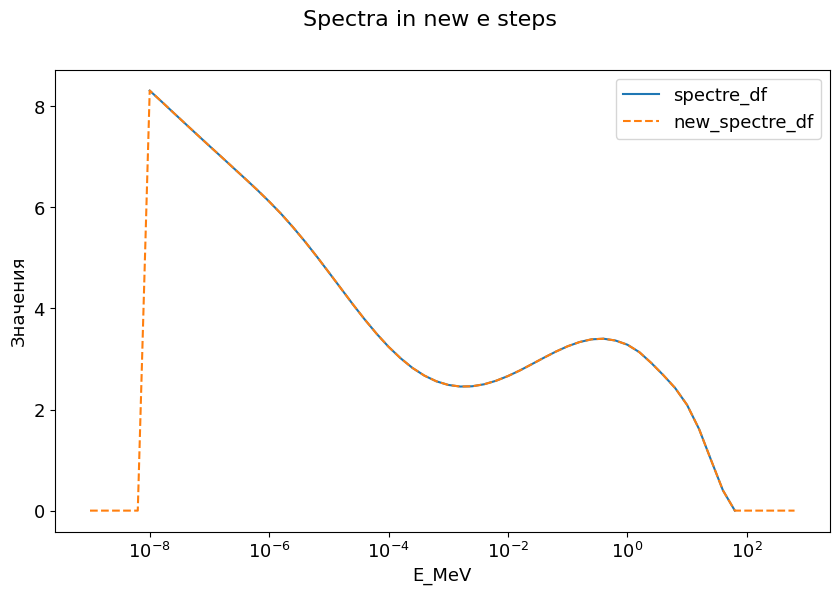

In [36]:
# новые энергии выбраны только до 631 МэВ!
fig = plt.figure(figsize=(10, 6))
fig.suptitle("Spectra in new e steps", fontsize=16)
ax = fig.add_subplot(111)
ax.set_xscale("log")

ax.plot(spectre_df["E_MeV"], spectre_df['Phi'], label='spectre_df')
ax.plot(new_spectre_df["E_MeV"], new_spectre_df['Phi'], label='new_spectre_df', linestyle="--")

ax.legend(loc="upper right")
ax.set_xlabel("E_MeV")
ax.set_ylabel("Значения")
plt.show()

Расчёт эффективного показания спектрометра по спектру

In [37]:
# умножаем Матрицу чувствительности на функцию спектра и получаем Q
def calculate_Q(A, phi):
    """
    A - matrix
    phi - spectre
    Calculate Q value for spheres

    """
    Q = A.T @ phi
    return Q

так нужно сделать для всех спектров из компендиума - чтобы получить эффективные Q для разных приборов.

In [38]:
Q1 = calculate_Q(A1, new_spectre_df['Phi'])
Q1

array([ 7.52029929,  1.36831753, 12.39232866, 15.10015109, 13.14638657,
        6.20312308,  3.61684968,  2.15320451,  5.37658133])

______________________________

# Проверим на эталонном спектре

из-за немного разного подхода к интегрированию, у нас с компендиумом различаются Q_eff, возможно они брали середину диапазона а не левый край. ну и у нас при интерполяции и другой разбивке на бины тоже отличие

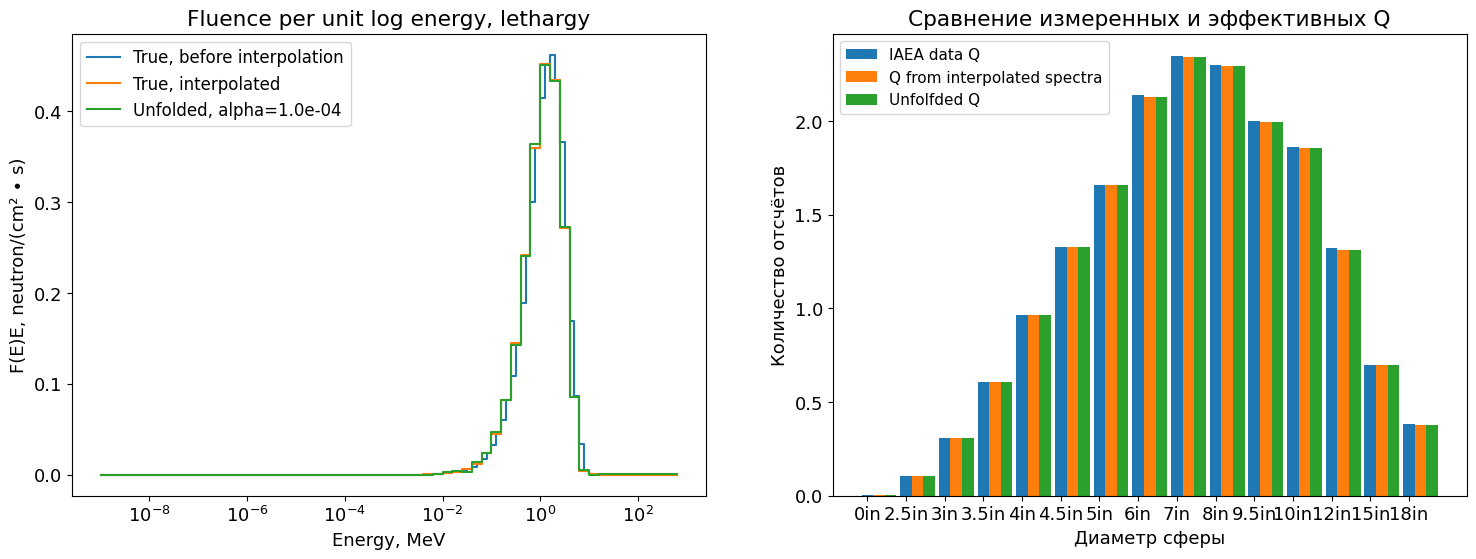

In [ ]:
# Исходные данные
# Рассчитанные эффективные Q по табличным данным из компендиума (с. 85) - проверяю, правильно ли мы интегрируем
Q_eff_BS3He = np.array([6.91E-04, 1.07E-01, 3.09E-01, 6.09E-01, 9.66E-01, 1.33E+00, 1.66E+00, 2.14E+00, 2.35E+00, 2.30E+00, 2.00E+00, 1.86E+00, 1.32E+00, 7.00E-01, 3.81E-01])  # PTB
# 1-й спектр
ISO_spectra_df_all = pd.read_csv('Data/Spectra/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
ISO_spectra_df_test = ISO_spectra_df_all[['E_MeV','ISO_ref_Cf252']] # ISO, unmoderated Cf

# конвертируем спектр на нужную нам сетку
ISO_spectra_new = convert_spectre_energy_steps(ISO_spectra_df_test, new_ebins, Emin=1e-9)

new_rf_df = Convert_RF('Data/Response_functions/RF_PTB.csv', new_ebins, method="pchip")   # Прибор PTB 3He
Amat, _, _, _ = convert_rf_to_matrix_variable_step(new_rf_df, Emin=1e-9)

ISO_spectra__eff_Q = calculate_Q(Amat, ISO_spectra_new['Phi']) # эффективные Q по спектру

#---------------------------------------------------------------------------------------
# Теперь используем ISO_spectra__eff_Q как начальные данные для восстановления спектра
# Восстановим через сvxpy

alpha = 1e-4
b = np.array(ISO_spectra__eff_Q)
A = Amat.T # нужно транспонировать A.shape = (15, 60)
# Создаем переменную
x = cp.Variable(A.shape[1], nonneg=True)

# Целевая функция с регуляризацией (Tikhonov regularization)
objective = cp.Minimize(cp.norm(A @ x - b, 2) + alpha * cp.norm(x, 2))

# Формулируем и решаем задачу
problem = cp.Problem(objective)
problem.solve()

Q_unfolded = calculate_Q(Amat, x.value)
#print('Решение:', x.value)


#---------------------------------------------------------------------------------------
# Визуализация
plt.rcParams["figure.figsize"] = (18, 6)
plt.rcParams["lines.markeredgewidth"] = 0.2
plt.rcParams.update({"font.size": 13})


fig, ax = plt.subplots(1, 2)
ax[0].set_title("Fluence per unit log energy, lethargy")
ax[0].step(ISO_spectra_df_test['E_MeV'], ISO_spectra_df_test['ISO_ref_Cf252'], label="True, before interpolation") 
ax[0].step(ISO_spectra_new['E_MeV'], ISO_spectra_new['Phi'], label="True, interpolated")
ax[0].step(ISO_spectra_new['E_MeV'], x.value, label=f"Unfolded, alpha={alpha:.1e}")

ax[0].set(xlabel="Energy, MeV", ylabel="F(E)E, neutron/(cm² ∙ s)")
ax[0].set_xscale("log")
ax[0].legend(prop={"size": 12})


labels = new_rf_df.keys()[1:]  # Пример названий сфер
x = np.arange(len(labels))
width = 0.30
nbars = 4
xstep = width * nbars

ax[1].bar(x , Q_eff_BS3He, width, label="IAEA data Q")  # x + xstep / nbars
ax[1].bar(x+ xstep / nbars, ISO_spectra__eff_Q, width, label="Q from interpolated spectra")  # x + xstep / nbars
ax[1].bar(x+ 2*xstep / nbars, Q_unfolded, width, label="Unfolfded Q")  # x + xstep / nbars

ax[1].set_xticks(x, labels)
ax[1].set_xlabel("Диаметр сферы")
ax[1].set_ylabel("Количество отсчётов")
ax[1].set_title("Сравнение измеренных и эффективных Q")
ax[1].legend(prop={"size": 11})

plt.show()

__То же самое но для GSF__
- в компендиуме отсутствуют данные для 2-х сфер: 5 и 12 дюймов

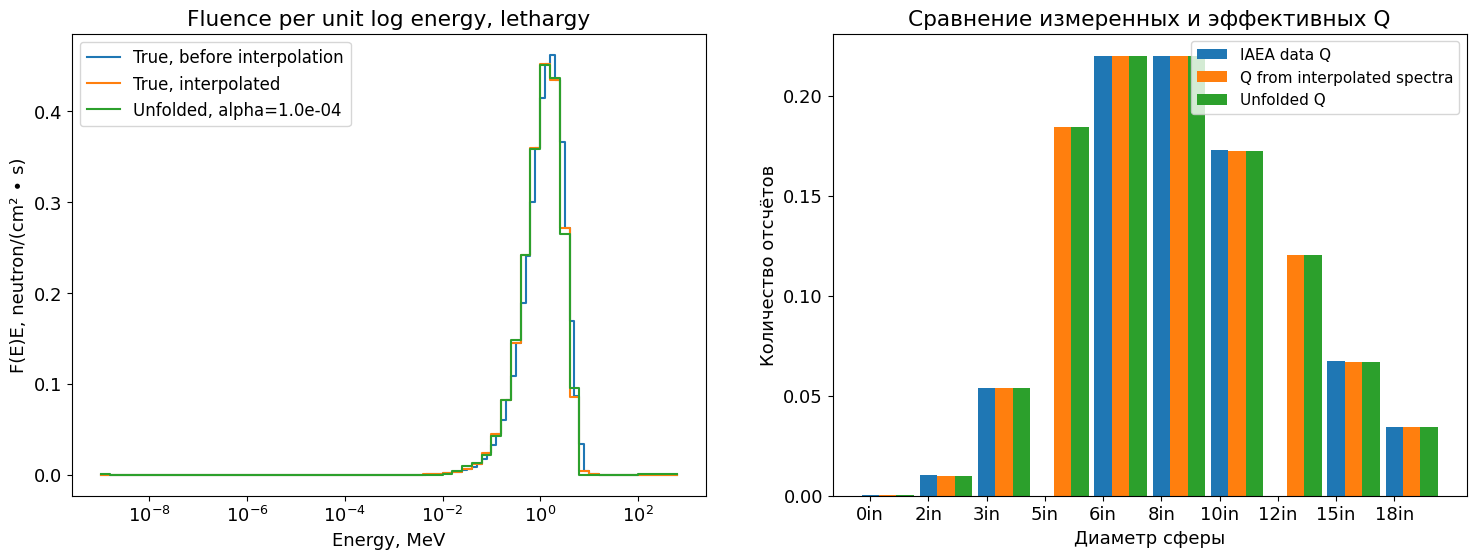

In [ ]:
Q_eff_BSLi = np.array([4.43E-04, 1.01E-02, 5.39E-02, np.nan, 2.20E-01, 2.20E-01, 1.73E-01, np.nan, 6.73E-02, 3.44E-02])  #GSF - в таблице не все данныые, отсутствующие заменил на np.nan.
# 1-й спектр
ISO_spectra_df_all = pd.read_csv('/Data/Spectra/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
ISO_spectra_df_test = ISO_spectra_df_all[['E_MeV','ISO_ref_Cf252']] # ISO, unmoderated Cf

# конвертируем спектр на нужную нам сетку
ISO_spectra_new = convert_spectre_energy_steps(ISO_spectra_df_test, new_ebins, Emin=1e-9)

new_rf_df = Convert_RF('Data/Response_functions/RF_GSF.csv', new_ebins, method="pchip")   # Прибор GSF LiI
Amat, _, _, _ = convert_rf_to_matrix_variable_step(new_rf_df, Emin=1e-9)

ISO_spectra__eff_Q = calculate_Q(Amat, ISO_spectra_new['Phi']) # эффективные Q по спектру

#---------------------------------------------------------------------------------------
# Теперь используем ISO_spectra__eff_Q как начальные данные для восстановления спектра
# Восстановим через сvxpy
alpha = 1e-4
b = np.array(ISO_spectra__eff_Q)
A = Amat.T # нужно транспонировать A.shape = (15, 60)
# Создаем переменную
x = cp.Variable(A.shape[1], nonneg=True)

# Целевая функция с регуляризацией (Tikhonov regularization)
objective = cp.Minimize(cp.norm(A @ x - b, 2) + alpha * cp.norm(x, 2))

# Формулируем и решаем задачу
problem = cp.Problem(objective)
problem.solve()

Q_unfolded = calculate_Q(Amat, x.value)
#print('Решение:', x.value)


#---------------------------------------------------------------------------------------
# Визуализация
plt.rcParams["figure.figsize"] = (18, 6)
plt.rcParams["lines.markeredgewidth"] = 0.2
plt.rcParams.update({"font.size": 13})


fig, ax = plt.subplots(1, 2)
ax[0].set_title("Fluence per unit log energy, lethargy")
ax[0].step(ISO_spectra_df_test['E_MeV'], ISO_spectra_df_test['ISO_ref_Cf252'], label="True, before interpolation") 
ax[0].step(ISO_spectra_new['E_MeV'], ISO_spectra_new['Phi'], label="True, interpolated")
ax[0].step(ISO_spectra_new['E_MeV'], x.value, label=f"Unfolded, alpha={alpha:.1e}")

ax[0].set(xlabel="Energy, MeV", ylabel="F(E)E, neutron/(cm² ∙ s)")
ax[0].set_xscale("log")
ax[0].legend(prop={"size": 12})


labels = new_rf_df.keys()[1:]  # Пример названий сфер
x = np.arange(len(labels))
width = 0.30
nbars = 4
xstep = width * nbars

ax[1].bar(x , Q_eff_BSLi, width, label="IAEA data Q")  # x + xstep / nbars
ax[1].bar(x+ xstep / nbars, ISO_spectra__eff_Q, width, label="Q from interpolated spectra")  # x + xstep / nbars
ax[1].bar(x+ 2*xstep / nbars, Q_unfolded, width, label="Unfolded Q")  # x + xstep / nbars

ax[1].set_xticks(x, labels)
ax[1].set_xlabel("Диаметр сферы")
ax[1].set_ylabel("Количество отсчётов")
ax[1].set_title("Сравнение измеренных и эффективных Q")
ax[1].legend(prop={"size": 11})

plt.show()